# Волновое уравнение

Одномерное волновое уравнение для малых поперечных колебаний струны:

## $\frac{\partial^2u}{\partial{t^2}} = c^2 \frac{\partial^2u}{\partial{x^2}}$   

## $x \in [0, L], L=1$

## $c = 1$ - скорость волны

## Граничные условия: 
1. ### $u(0, t) = u(L, t) = 0$ - закрепленные концы
2. ### $\frac{\partial{u}}{\partial{x}}(L,t) = 0 $ - свободный конец


## Начальные условия: 
1. ### $ u(x, 0) = f(x)$ - начальная форма
2. ### $\frac{\partial{u}}{\partial{t}}(x,0) = g(x)$ - начальная скорость







### Полная энергия системы $E(t) = \int{[(\frac{\partial{u}}{\partial{t}})^2+c^2(\frac{\partial{u}}{\partial{x}})^2]}dx$

# Схема "Крест"

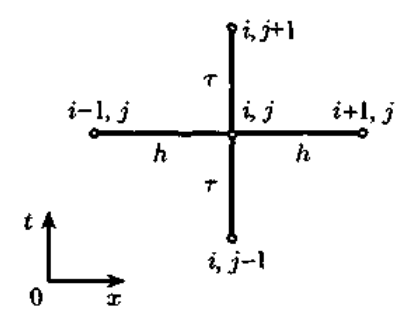

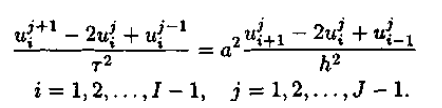

Выражение функции на $(j+1)$ слое

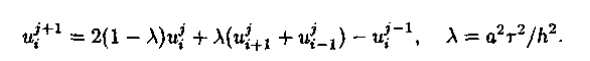

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [ ]:
# Параметры задачи
L = 1.0
c = 1.0

In [ ]:
# Функции начальных условий
def initial_f(x):
    x_mid = L / 2
    height = 0.5
    return np.where(x <= x_mid,
                    (height / x_mid) * x,
                    (height / (x_mid - L)) * (x - L))
def initial_g(x):
    return np.zeros_like(x)

def standing_wave(x, n):
    return 0.5 * np.sin(n * np.pi * x / L)

In [ ]:
# Схема "крест"
def solve_wave_equation(cfl, bc_type='fixed', initial_shape='triangle', mode=1, T=2.0):
    dx = 0.01
    x = np.arange(0, L + dx, dx)
    Nx = len(x)
    dt = cfl * dx / c
    t = np.arange(0, T + dt, dt)
    Nt = len(t)
    u = np.zeros((Nt, Nx))
    if initial_shape == 'triangle':
        u[0, :] = initial_f(x)
    elif initial_shape == 'standing_wave':
        u[0, :] = standing_wave(x, mode)

    # Первый шаг
    u[1, 1:-1] = u[0, 1:-1] + 0.5 * (cfl**2) * (u[0, 2:] - 2*u[0, 1:-1] + u[0, :-2])
    if bc_type == 'fixed':
        u[1, 0] = 0
        u[1, -1] = 0
    elif bc_type == 'free':
        u[1, 0] = u[1, 1]
        u[1, -1] = u[1, -2]

    # Основной цикл
    for n in range(1, Nt-1):
        u[n+1, 1:-1] = (2 * (1 - cfl**2) * u[n, 1:-1] +
                        cfl**2 * (u[n, 2:] + u[n, :-2]) -
                        u[n-1, 1:-1])
        if bc_type == 'fixed':
            u[n+1, 0] = 0
            u[n+1, -1] = 0
        elif bc_type == 'free':
            u[n+1, 0] = u[n+1, 1]
            u[n+1, -1] = u[n+1, -2]

    return x, t, u, dt

In [ ]:
# Функция для создания и отображения анимации
def create_and_show_animation(x, u, dt, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, L)
    ax.set_ylim(-0.6, 0.6)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.set_title(title)
    ax.grid(True)

    line, = ax.plot(x, u[0, :], 'b-', lw=2)
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

    def animate(i):
        line.set_ydata(u[i, :])
        time_text.set_text(f'Время: {i * dt:.2f} с')
        return line, time_text

    anim = FuncAnimation(fig, animate, frames=len(u), interval=50, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
# Треугольный профиль с закрепленными концами
cfl_values = [0.5, 1.0]
for cfl in cfl_values:
    x, t, u, dt = solve_wave_equation(cfl, bc_type='fixed', initial_shape='triangle', T=3.0)
    display(create_and_show_animation(x, u, dt, f'Треугольный профиль (CFL={cfl})'))


In [ ]:
# Различные граничные условия
x, t, u_fixed, dt = solve_wave_equation(0.5, bc_type='fixed', initial_shape='triangle', T=3.0)
display(create_and_show_animation(x, u_fixed, dt, 'Закрепленные концы'))


In [ ]:
x, t, u_free, dt = solve_wave_equation(0.5, bc_type='free', initial_shape='triangle', T=3.0)
display(create_and_show_animation(x, u_free, dt, 'Свободные концы'))


In [ ]:
# Стоячие волны
for mode in range(1, 4):
    x, t, u, dt = solve_wave_equation(0.5, bc_type='fixed',
                                     initial_shape='standing_wave', mode=mode, T=4.0)
    display(create_and_show_animation(x, u, dt, f'Стоячая волна - мода {mode}'))


In [ ]:
# Исследование неустойчивости при CFL > 1
x, t, u_unstable, dt = solve_wave_equation(1.05, bc_type='fixed', initial_shape='triangle', T=1.5)
display(create_and_show_animation(x, u_unstable, dt, 'Неустойчивость при CFL=1.05'))


In [ ]:
# Анализ энергии
def calculate_energy(u, x, t, c):
    dt = t[1] - t[0]
    dx = x[1] - x[0]
    dudt = np.gradient(u, dt, axis=0)
    dudx = np.gradient(u, dx, axis=1)
    energy_density = dudt**2 + (c * dudx)**2
    total_energy = np.trapezoid(energy_density, x, axis=1)
    return total_energy


In [ ]:
# График сохранения энергии
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Энергия для разных CFL
for idx, cfl in enumerate([0.5, 1.0]):
    x, t, u, dt = solve_wave_equation(cfl, bc_type='fixed', initial_shape='triangle')
    energy = calculate_energy(u, x, t, c)
    axes[0, idx].plot(t, energy)
    axes[0, idx].set_title(f'Энергия (CFL={cfl})')
    axes[0, idx].set_xlabel('Время')
    axes[0, idx].set_ylabel('Энергия')
    axes[0, idx].grid(True)

# Энергия для разных граничных условий
x, t, u_fixed, dt = solve_wave_equation(0.5, bc_type='fixed', initial_shape='triangle')
energy_fixed = calculate_energy(u_fixed, x, t, c)
axes[1, 0].plot(t, energy_fixed)
axes[1, 0].set_title('Энергия (закрепленные концы)')
axes[1, 0].set_xlabel('Время')
axes[1, 0].set_ylabel('Энергия')
axes[1, 0].grid(True)

x, t, u_free, dt = solve_wave_equation(0.5, bc_type='free', initial_shape='triangle')
energy_free = calculate_energy(u_free, x, t, c)
axes[1, 1].plot(t, energy_free)
axes[1, 1].set_title('Энергия (свободные концы)')
axes[1, 1].set_xlabel('Время')
axes[1, 1].set_ylabel('Энергия')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()
